In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from transformers import AutoTokenizer, AutoModelForCausalLM, logging

import torch

from datasets import load_dataset

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
logging.set_verbosity_error()
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neo-125m')
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

# load in GPTneo
model = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m').to(device)
model.eval()

embed_dim = model.config.hidden_size

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

In [4]:
# Implant a hook for each of the transfoermer layers
activations = {}

for layeri in range(model.config.num_layers):
  hook_name = f'mlp_{layeri}'
  model.transformer.h[layeri].mlp.c_fc.register_forward_hook(lambda module, input, output, hook_name=hook_name: activations.__setitem__(hook_name, output.detach()))


In [5]:
# TEST
text = 'This is a Python code'
input_ids = tokenizer(text, return_tensors='pt').input_ids.to(device)
output = model(input_ids)

In [6]:
num_neurons = model.transformer.h[0].mlp.c_fc.weight.shape[0]

# Analyze token lengths of HF's fineweb dataset

In [7]:
fw = load_dataset('HuggingFaceFW/fineweb', split='train', streaming=True)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

In [8]:
fw_iterator = iter(fw)
for _ in range(5):
  print('\n',next(fw_iterator)['text'])


 How AP reported in all formats from tornado-stricken regionsMarch 8, 2012
When the first serious bout of tornadoes of 2012 blew through middle America in the middle of the night, they touched down in places hours from any AP bureau. Our closest video journalist was Chicago-based Robert Ray, who dropped his plans to travel to Georgia for Super Tuesday, booked several flights to the cities closest to the strikes and headed for the airport. He’d decide once there which flight to take.
He never got on board a plane. Instead, he ended up driving toward Harrisburg, Ill., where initial reports suggested a town was destroyed. That decision turned out to be a lucky break for the AP. Twice.
Ray was among the first journalists to arrive and he confirmed those reports -- in all formats. He shot powerful video, put victims on the phone with AP Radio and played back sound to an editor who transcribed the interviews and put the material on text wires. He then walked around the devastation with the 

In [9]:
# Extract 8192 tokens from the dataset
tokens2Extract = 8192

# Initialize a list to capture all tokens (this is more efficient for dynamic accumulation)
all_tokens = torch.tensor([], dtype=torch.long).to(device)

# Initialize an array to store the token lengths
token_lengths = np.array([])

# Initialize the iterator
fw_iterator = iter(fw)

while all_tokens.numel() < tokens2Extract:

    #Extract the text from FineWeb
    text = next(fw_iterator)['text']

    #Encode the text and ensure it's 1D
    # The tokenizer returns a (batch_size, sequence_length) tensor. Squeeze(0) to remove the batch_size dimension.
    token_ids = tokenizer(text, return_tensors='pt').input_ids.to(device).squeeze(0)

    # Fill the token_lengths array with the length of the tokens (after potential truncation)
    tok_lengths = np.array([len(tokenizer.decode(t)) for t in token_ids])

    # Concatenate all collected 1D tensors into a single 1D tensor
    all_tokens = torch.cat((all_tokens, token_ids), dim=-1)

    # Concatenate token lengths
    token_lengths = np.concatenate((token_lengths, tok_lengths))

# Extract the desired number of tokens only
all_tokens = all_tokens[:tokens2Extract]
token_lengths = token_lengths[:tokens2Extract]

print(f'Total number of tokens: {all_tokens.numel()}')
print(f'Total number of token lengths: {len(token_lengths)}')


Total number of tokens: 8192
Total number of token lengths: 8192


In [10]:
unique_toks, count = np.unique(token_lengths, return_counts=True)
median_tok_length = np.median(token_lengths)
print(f'Median token length: {median_tok_length}')

Median token length: 4.0


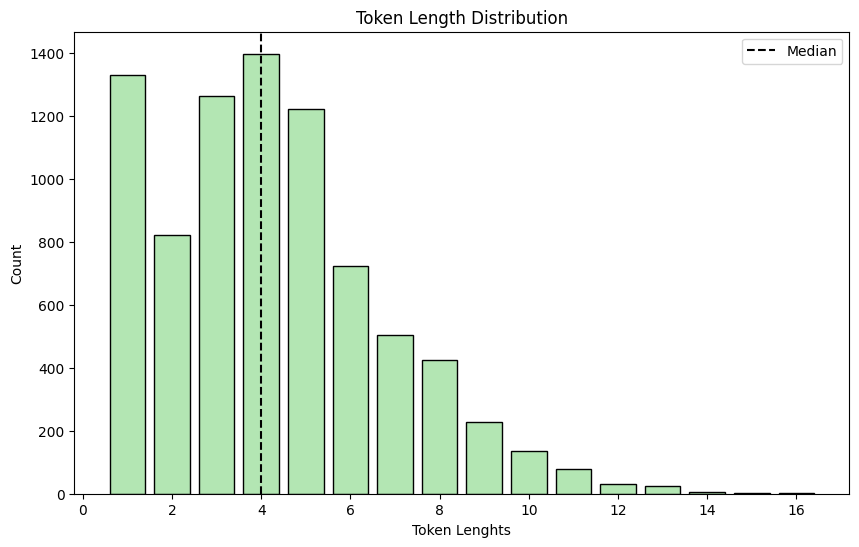

In [11]:
# Visualize
plt.figure(figsize=(10, 6))
plt.bar(unique_toks, count, color=[.7,.9,.7], edgecolor='k')
plt.axvline(x=median_tok_length, color='k', linestyle='--', label='Median')
plt.legend()
plt.xlabel('Token Lenghts')
plt.ylabel('Count')
plt.title('Token Length Distribution')
plt.show()

In [12]:
# Summarize
print(f'Number of tokens shorter than median length: {np.sum(token_lengths < median_tok_length):,}')
print(f'Number of tokens equal to median length: {np.sum(token_lengths == median_tok_length):,}')
print(f'Number of tokens longer than median length: {np.sum(token_lengths > median_tok_length):,}')


Number of tokens shorter than median length: 3,414
Number of tokens equal to median length: 1,397
Number of tokens longer than median length: 3,381


In [13]:
# Oraganize the tokens into 16x512 batches
batch_size = 16
batch_length = 512
all_tokens_batched = all_tokens.view(batch_size, batch_length).to(device)

# Run the tokens through the model
with torch.no_grad(): model(all_tokens_batched)
#
# Verify the shape of activation of any one hook
print(f'Shape of activations: {activations["mlp_0"].shape}')

Shape of activations: torch.Size([16, 512, 3072])


### Activations for tokens that are shorter, equal and longer than median length from the 5th transformer block

In [14]:
activ_tokens = activations['mlp_4'].view(-1, num_neurons)
activ_tokens.shape


torch.Size([8192, 3072])

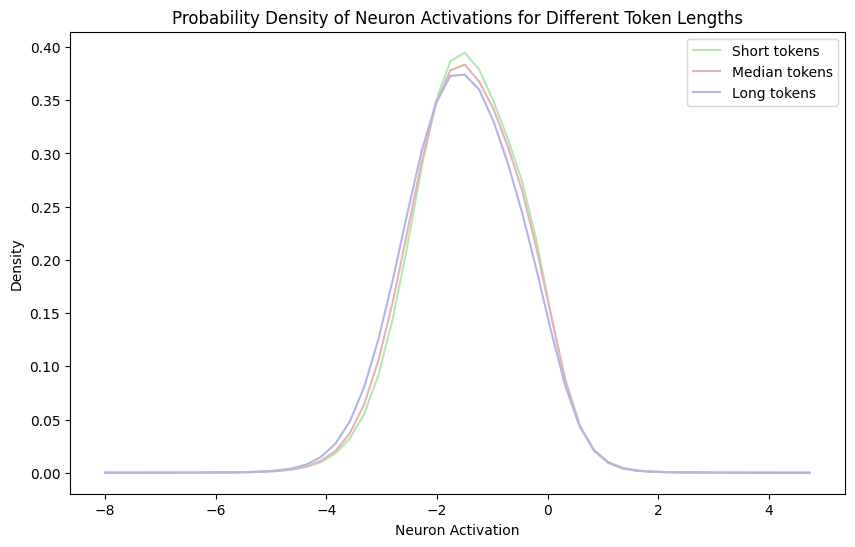

In [16]:
binedges = np.linspace(-8,5,51)

# Activations by lengths
y_short, x_short = np.histogram(activ_tokens[token_lengths < median_tok_length].cpu(), bins=binedges, density=True)
y_equal, x_equal = np.histogram(activ_tokens[token_lengths == median_tok_length].cpu(), bins=binedges, density=True)
y_long, x_long = np.histogram(activ_tokens[token_lengths > median_tok_length].cpu(), bins=binedges, density=True)

plt.figure(figsize=(10, 6))
plt.plot(x_short[:-1], y_short, label='Short tokens', color=[.7,.9,.7])
plt.plot(x_equal[:-1], y_equal, label='Median tokens', color=[.9,.7,.7])
plt.plot(x_long[:-1], y_long, label='Long tokens', color=[.7,.7,.9])

plt.xlabel('Neuron Activation')
plt.ylabel('Density')
plt.title('Probability Density of Neuron Activations for Different Token Lengths')
plt.legend()
plt.show()

#### **Standardize the acivations and the length matrix and find covariance and Personian correlation between the two**

In [78]:
acts = activations['mlp_4'].view(-1, num_neurons).cpu().numpy()

# Stabdardize activations over all neurons
z_acts = (acts - acts.mean(axis=0)) / acts.std(axis=0, ddof=1, keepdims=True)

In [83]:
z_acts.shape, z_acts[:,500].mean(), z_acts[:,500].std(ddof=1)

((8192, 3072), np.float32(1.5310943e-06), np.float32(1.0000002))

In [84]:
z_token_lengths = (token_lengths - token_lengths.mean()) / token_lengths.std(ddof=1)
#

In [85]:
z_token_lengths.shape, z_token_lengths.mean(), z_token_lengths.std(ddof=1)

((8192,), np.float64(-8.673617379884035e-18), np.float64(1.0))

In [87]:
# Calculate correlation coeffiecient of one neuron
np.corrcoef(z_acts[:,500], z_token_lengths)[0,1]

np.float64(0.17302468940000998)

In [88]:
# Calculate covariance of one neurson
cov = sum(z_acts[:,500] * z_token_lengths)/ (tokens2Extract-1)
cov

np.float64(0.1730247243997406)

In [89]:
# Calculate all correlation coeffeicients
all_corrcoefs = np.zeros(num_neurons)

for i in range(num_neurons):
  all_corrcoefs[i] = np.corrcoef(z_acts[:,i], z_token_lengths)[0,1]

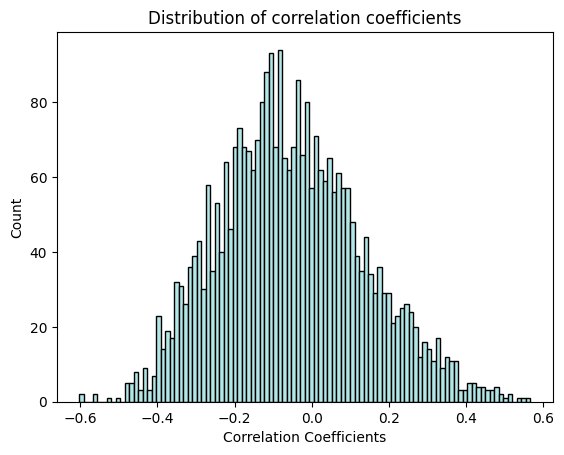

In [100]:
# Visualize through histogram

plt.hist(all_corrcoefs, bins=100, color=[.7,.9,.9], edgecolor='k')
plt.xlabel('Correlation Coefficients')
plt.ylabel('Count')
plt.title('Distribution of correlation coefficients')

plt.show()

#### **Correlation of token activations vs lengths in all layers**

In [102]:
allCorrs = np.zeros((model.config.num_layers,num_neurons))

# loop over all the layers
for layeri in range(model.config.num_layers):

  # get and normalize the activations
  acts = activations[f'mlp_{layeri}'].reshape(-1,num_neurons).cpu().numpy()
  zacts = (acts-acts.mean(axis=0,keepdims=True)) / np.std(acts,axis=0,ddof=1,keepdims=True)

  # loop over all the neurons and correlate
  for ni in range(num_neurons):
    allCorrs[layeri,ni] = sum(z_token_lengths*zacts[:,ni]) / (tokens2Extract-1)

In [103]:
# histograms
rEdges = torch.linspace(-.8,.8,81)
rHistCounts = np.zeros((model.config.num_layers,len(rEdges)-1))

# get histogram of each layer
for layeri in range(model.config.num_layers):
  rHistCounts[layeri,:],_ = np.histogram(allCorrs[layeri,:],bins=rEdges,density=True)

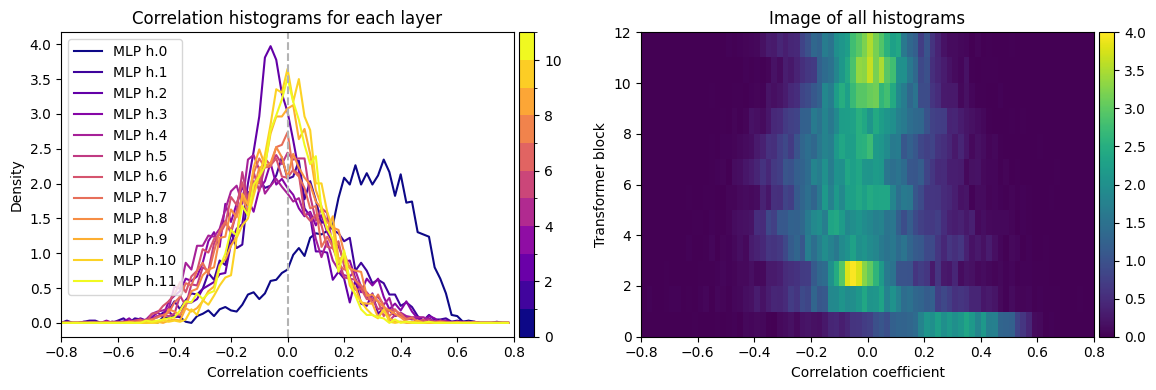

In [104]:
# and visualize
fig,axs = plt.subplots(1,2,figsize=(12,4))

for layeri in range(model.config.num_layers):
  axs[0].plot(rEdges[:-1],rHistCounts[layeri,:],color=mpl.cm.plasma(layeri/(model.config.num_layers-1)),label=f'MLP h.{layeri}')

axs[0].legend()
axs[0].axvline(0,linestyle='--',color=[.7,.7,.7])
axs[0].set(xlabel='Correlation coefficients',ylabel='Density',xlim=rEdges[[0,-1]],
           title='Correlation histograms for each layer')

# colorbar for line color (layer number)
cmap = mpl.colormaps['plasma']
norm = mpl.colors.BoundaryNorm(np.arange(model.config.num_layers), cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axs[0], pad=.01)


# image
h = axs[1].imshow(rHistCounts,aspect='auto',vmin=0,vmax=4,origin='lower',extent=[rEdges[0],rEdges[-1],0,model.config.num_layers])
axs[1].set(xlabel='Correlation coefficient',ylabel='Transformer block',title='Image of all histograms')
fig.colorbar(h,ax=axs[1],pad=.01)

plt.tight_layout()
plt.show()

# Repeat for neo-1.3B model

In [105]:
logging.set_verbosity_error()
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neo-1.3B')
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

# load in GPTneo
model = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-1.3B').to(device)
model.eval()

embed_dim = model.config.hidden_size

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.31G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/316 [00:00<?, ?it/s]

In [107]:
# Implant a hook for each of the transfoermer layers
activations = {}

for layeri in range(model.config.num_layers):
  hook_name = f'mlp_{layeri}'
  model.transformer.h[layeri].mlp.c_fc.register_forward_hook(lambda module, input, output, hook_name=hook_name: activations.__setitem__(hook_name, output.detach()))


In [110]:
# Run the tokens through the model
with torch.no_grad(): model(all_tokens_batched)
#
# Verify the shape of activation of any one hook
print(f'Shape of activations: {activations["mlp_0"].shape}')

Shape of activations: torch.Size([16, 512, 8192])


In [113]:
num_neurons = model.transformer.h[0].mlp.c_fc.weight.shape[0]

allCorrs = np.zeros((model.config.num_layers,num_neurons))

# loop over all the layers
for layeri in range(model.config.num_layers):

  # get and normalize the activations
  acts = activations[f'mlp_{layeri}'].reshape(-1,num_neurons).cpu().numpy()
  zacts = (acts-acts.mean(axis=0,keepdims=True)) / np.std(acts,axis=0,ddof=1,keepdims=True)

  # loop over all the neurons and correlate
  for ni in range(num_neurons):
    allCorrs[layeri,ni] = sum(z_token_lengths*zacts[:,ni]) / (tokens2Extract-1)

In [114]:
# histograms
rEdges = torch.linspace(-.8,.8,81)
rHistCounts = np.zeros((model.config.num_layers,len(rEdges)-1))

# get histogram of each layer
for layeri in range(model.config.num_layers):
  rHistCounts[layeri,:],_ = np.histogram(allCorrs[layeri,:],bins=rEdges,density=True)

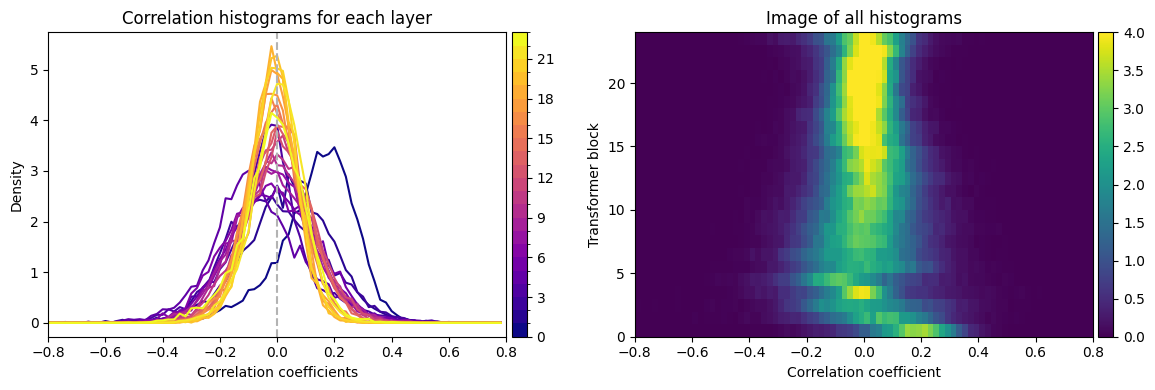

In [126]:
# and visualize
fig,axs = plt.subplots(1,2,figsize=(12,4))

for layeri in range(model.config.num_layers):
  axs[0].plot(rEdges[:-1],rHistCounts[layeri,:],color=mpl.cm.plasma(layeri/(model.config.num_layers-1)),label=f'MLP h.{layeri}')

axs[0].axvline(0,linestyle='--',color=[.7,.7,.7])
axs[0].set(xlabel='Correlation coefficients',ylabel='Density',xlim=rEdges[[0,-1]],
           title='Correlation histograms for each layer')

# colorbar for line color (layer number)
cmap = mpl.colormaps['plasma']
norm = mpl.colors.BoundaryNorm(np.arange(model.config.num_layers), cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axs[0], pad=.01)


# image
h = axs[1].imshow(rHistCounts,aspect='auto',vmin=0,vmax=4,origin='lower',extent=[rEdges[0],rEdges[-1],0,model.config.num_layers])
axs[1].set(xlabel='Correlation coefficient',ylabel='Transformer block',title='Image of all histograms')
fig.colorbar(h,ax=axs[1],pad=.01)

plt.tight_layout()
plt.show()